In [1]:
#   Copyright 2022 - 2026 The PyMC Labs Developers
#
#   Licensed under the Apache License, Version 2.0 (the "License");
#   you may not use this file except in compliance with the License.
#   You may obtain a copy of the License at
#
#       http://www.apache.org/licenses/LICENSE-2.0
#
#   Unless required by applicable law or agreed to in writing, software
#   distributed under the License is distributed on an "AS IS" BASIS,
#   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#   See the License for the specific language governing permissions and
#   limitations under the License.
"""Halo effects in multi-dimensional media mix models (experiment notebook)."""
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.16.7
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

'Halo effects in multi-dimensional media mix models (experiment notebook).'

# Halo Effects in Multi-Dimensional Media Mix Models

## Motivation

In brand portfolios — whether in automotive, consumer electronics, fashion, or
any industry with multiple products under one umbrella — a **flagship product's**
advertising often lifts awareness and consideration for the entire portfolio.
This cross-product spillover is called the **halo effect**.

Consider a company with three products in its portfolio:

| Product | Role |
|---------|------|
| Product A | Flagship awareness driver (highest ad spend, most recognisable) |
| Product B | Mid-range offering, benefits from brand consideration |
| Product C | Complementary product, benefits from brand consideration |

When the company runs a major TV campaign for Product A, three things happen:

1. **Direct effect** — Product A sales increase.
2. **Brand halo** — The campaign lifts overall brand awareness, driving
   consideration for *all* products.
3. **Product halo** — Interest in Product A drives cross-shopping to
   Products B and C.

A standard Media Mix Model (MMM) captures (1) but completely misses (2) and (3),
leading to **biased ROAS** (non-flagship products get credit for halo-driven sales)
and **misallocated budgets** (the flagship is under-valued).

This notebook generates synthetic data with a known halo structure, then fits
multiple models — a baseline MMM with no halo and several halo-aware variants —
to compare parameter recovery and model fit.

## Business Implications

Ignoring halo effects in an MMM leads to concrete business problems:

- **Biased ROAS estimates.** The flagship product appears to have *lower* ROAS
  than it truly does, because part of its media uplift materialises as sales of
  *other* products.  Those other products, in turn, appear to have *higher* ROAS
  because their intercepts absorb the halo-driven sales they did not earn
  themselves.

- **Budget misallocation.** If the flagship's true portfolio-wide ROI is
  under-estimated, optimisation routines will systematically under-invest in
  the flagship and over-invest in non-flagship products whose apparent
  performance is inflated.

- **Portfolio strategy.** The total value of a flagship campaign is its direct
  effect *plus* the halo-driven sales across the portfolio.  Quantifying this
  total informs strategic decisions such as whether to increase the flagship's
  media budget, launch a new flagship candidate, or reallocate spend from
  non-flagship products whose standalone ROAS does not justify their budgets
  once halo is accounted for.

## The Standard Multi-Dimensional MMM

The `MMM` class in `pymc_marketing.mmm.multidimensional` with `dims=("product",)`
estimates:

$$
y_{t,i} = \alpha_i
  + \sum_{m=1}^{M} \beta_{m,i}\, f_m\!\bigl(\{x_{m,s,i}\}_{s \le t}\bigr)
  + \sum_{c} \gamma_{c,i}\, z_{c,t,i}
  + \varepsilon_{t,i}
$$

where $f_m$ chains an adstock transformation (geometric decay) with a saturation
transformation (logistic).  Crucially, the channel contribution for product $i$
depends **only** on product $i$'s own media spend — there is no cross-product
coupling.

## Approaches to Modeling Halo Effects

We denote the total media contribution for product $j$ at time $t$ as:

$$
C_{t,j} = \sum_{m=1}^{M} \beta_{m,j}\, f_m\!\bigl(\{x_{m,s,j}\}_{s \le t}\bigr)
$$

Before introducing structured halo models, two simpler workarounds are worth
mentioning:

**(a) Include all cross-product channels directly.**  For each product $i$,
add every other product's individual channel spend columns as additional media
or control inputs.  This explodes the number of parameters ($P \times M$
channels instead of $M$), making identification difficult with many
products or channels and leading to severe collinearity.

**(b) Aggregate cross-product spend as a control.**  For each product $i$,
compute the total media spend from all *other* products and include it as a
single control variable.  This is far more parsimonious and is the basis of
**Approach 0** below.

We now describe four progressively more structured approaches.

### Approach 0 — Aggregate Cross-Product Spend (Control Variable)

Define the total media spend from all products other than $i$ at time $t$:

$$
S_{t,i}^{\text{other}} = \sum_{j \neq i} \sum_{m=1}^{M} x_{m,t,j}
$$

and add it as a linear control:

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \gamma_i\, S_{t,i}^{\text{other}}
  + \varepsilon_{t,i}
$$

- Only $P$ extra parameters ($\gamma_i$).
- Uses the `MMM` class directly via `control_columns` -- no custom model needed.
- **Limitations:** the control uses *raw* spend (not adstocked or saturated),
  cannot distinguish *which* product's spend drives the halo, and a single
  linear coefficient conflates potentially very different spillover patterns.

### Approach 1 — Spillover Matrix

Introduce a matrix $H \in \mathbb{R}^{P \times P}$ capturing cross-product
spillover:

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \sum_{j=1}^{P} H_{ij}\, C_{t,j}
  + \varepsilon_{t,i}
$$

- $P^2$ halo parameters.
- Most flexible: can model arbitrary product-to-product effects.
- Hardest to identify with limited data.
- Priors: $H_{ij} \sim \text{HalfNormal}(\sigma)$ (positive spillover only).

### Approach 2 — Latent Brand Awareness Factor

Assume a single latent *brand awareness* signal driven by all products' media:

$$
A_t = \sum_{j=1}^{P} w_j\, C_{t,j}
\qquad\text{then}\qquad
y_{t,i} = \alpha_i + C_{t,i} + \lambda_i\, A_t + \varepsilon_{t,i}
$$

- $2P$ parameters ($w_j$ weights + $\lambda_i$ sensitivities).
- Rank-1 approximation of the spillover matrix: $H_{ij} \approx \lambda_i\, w_j$.
- Interpretable: "the flagship drives 60 % of brand awareness".
- Cannot model product-specific halo patterns beyond the shared factor.

### Approach 3 — Flagship-Specific Halo

When the awareness driver is known *a priori* (here, Product A):

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \delta_i\, C_{t,\text{flagship}}
  + \varepsilon_{t,i}
$$

with $\delta_{\text{flagship}} = 0$ to avoid double-counting.

- $P - 1$ halo parameters.
- Simplest; directly answers "how much does flagship advertising lift other
  products' sales?"
- Requires knowing which product is the awareness driver.

## Experiment Design

1. **Synthetic data** — We generate observations from a DGP that matches
   Approach 3 (flagship halo from Product A), using PyMC's `do()` +
   `sample_prior_predictive()` pattern.
2. **Baseline** — Fit the standard `MMM` class (no halo).
3. **Approach 0** — Fit the `MMM` class with aggregate cross-product spend as
   a control variable.
4. **Approach 1** — Fit a custom model with a full spillover matrix.
5. **Approach 2** — Fit a custom model with a latent brand awareness factor.
6. **Approach 3** — Fit a custom model with a flagship-specific halo (the
   "correct" model matching the DGP).
7. **Comparison** — Compare parameter recovery and posterior predictive fit.

---
## 1. Imports and Configuration

In [2]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
from pymc import do

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import MuEffect
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

warnings.filterwarnings("ignore", category=UserWarning, module="pymc.dims")
warnings.filterwarnings("ignore", category=UserWarning, module="pytensor.xtensor")
warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

/Users/juanitorduz/micromamba/envs/pymc-marketing-dev/lib/python3.13/site-packages/pymc/dims/__init__.py:66: UserWarning: The `pymc.dims` module is experimental and may contain critical bugs (p=0.080).
Please report any issues you encounter at https://github.com/pymc-devs/pymc/issues.
API changes are expected in future releases.

  __init__()


In [3]:
RANDOM_SEED: int = sum(map(ord, "halo"))
rng: np.random.Generator = np.random.default_rng(seed=RANDOM_SEED)

PRODUCTS: list[str] = ["product_a", "product_b", "product_c"]
CHANNELS: list[str] = ["tv", "digital"]
FLAGSHIP_IDX: int = 0  # product_a is the flagship awareness driver

N_DATES: int = 110
L_MAX: int = 8
DATE_RANGE = pd.date_range(start="2022-01-03", freq="W-MON", periods=N_DATES)

SAMPLER_CONFIG: dict = {
    "nuts_sampler": "nutpie",
    "chains": 2,
    "draws": 1_000,
    "tune": 1_000,
    "random_seed": RANDOM_SEED,
}

N_PRODUCTS = len(PRODUCTS)
N_CHANNELS = len(CHANNELS)

---
## 2. Synthetic Data Generation (DGP)

We follow the `do()` + `sample_prior_predictive()` pattern from the
[data generator notebook](../../docs/source/notebooks/mmm/mmm_data_generator.ipynb).

**Steps**:
1. Generate channel spend covariates per product.
2. Draw ground-truth parameter values from prior distributions via `pm.draw()`.
3. Build a custom PyMC model for the DGP that includes the halo structure, using
   the same `geometric_adstock` and `logistic_saturation` functions from
   `pymc_marketing.mmm.transformers`.
4. Clamp parameters to ground truth via `pymc.do()`.
5. Forward-sample with `pm.sample_prior_predictive(draws=1)`.

### 2.1 Generate Channel Spend Data

In [4]:
spend_scales = {
    "product_a": {"tv": 3.0, "digital": 2.0},
    "product_b": {"tv": 1.5, "digital": 1.8},
    "product_c": {"tv": 1.0, "digital": 1.5},
}

rows = []
for product in PRODUCTS:
    for _t, date in enumerate(DATE_RANGE):
        row = {"date": date, "product": product}
        for channel in CHANNELS:
            row[channel] = rng.exponential(scale=spend_scales[product][channel])
        rows.append(row)

spend_df = pd.DataFrame(rows)
spend_df["y_dummy"] = 1.0

spend_df.head(9)

,date,product,tv,digital,y_dummy
0,2022-01-03,product_a,12.414939,4.808479,1.0
1,2022-01-10,product_a,2.436129,2.606215,1.0
2,2022-01-17,product_a,2.554615,0.126160,1.0
3,2022-01-24,product_a,6.688069,0.419612,1.0
4,2022-01-31,product_a,1.007636,0.218574,1.0
5,2022-02-07,product_a,2.093762,1.664677,1.0
6,2022-02-14,product_a,2.915413,1.068183,1.0
7,2022-02-21,product_a,1.565229,6.491743,1.0
8,2022-02-28,product_a,8.907217,0.541069,1.0


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/3845482650.py:14: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


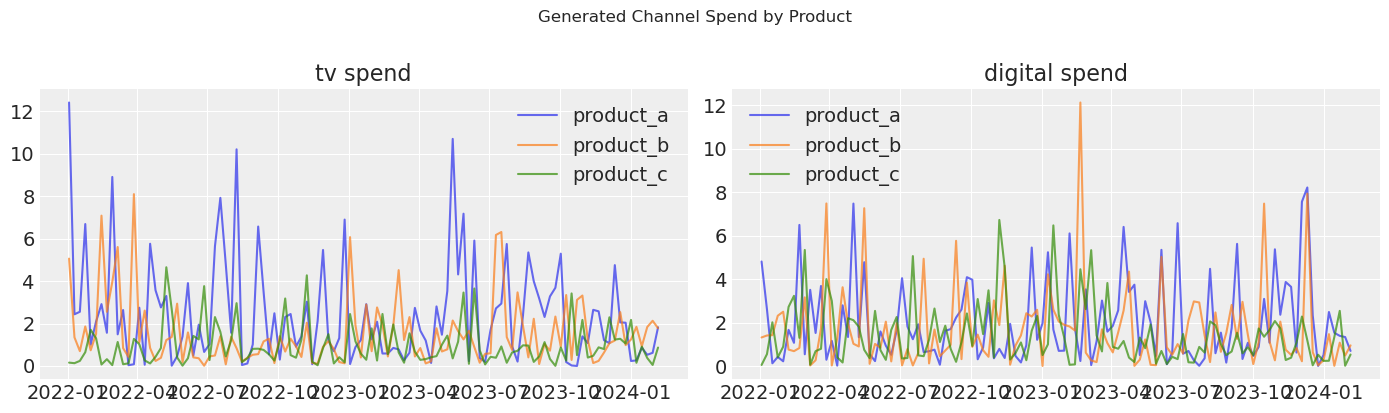

In [5]:
fig, axes = plt.subplots(1, N_CHANNELS, figsize=(14, 4), sharey=False)
for ax, channel in zip(axes, CHANNELS, strict=True):
    for product in PRODUCTS:
        mask = spend_df["product"] == product
        ax.plot(
            spend_df.loc[mask, "date"],
            spend_df.loc[mask, channel],
            label=product,
            alpha=0.7,
        )
    ax.set_title(f"{channel} spend")
    ax.legend()
fig.suptitle("Generated Channel Spend by Product", y=1.02)
fig.tight_layout()

### 2.2 Draw Ground-Truth Parameters

In [6]:
intercept_true = pm.draw(
    pm.Normal.dist(mu=5, sigma=1), draws=N_PRODUCTS, random_seed=rng
)

adstock_alpha_true = pm.draw(
    pm.Beta.dist(alpha=1, beta=3), draws=N_PRODUCTS * N_CHANNELS, random_seed=rng
).reshape(N_PRODUCTS, N_CHANNELS)

saturation_lam_true = pm.draw(
    pm.Gamma.dist(alpha=2, beta=1), draws=N_PRODUCTS * N_CHANNELS, random_seed=rng
).reshape(N_PRODUCTS, N_CHANNELS)

saturation_beta_true = pm.draw(
    pm.HalfNormal.dist(sigma=1), draws=N_PRODUCTS * N_CHANNELS, random_seed=rng
).reshape(N_PRODUCTS, N_CHANNELS)

# Halo coefficients: flagship has 0 self-halo, product_b gets 30%, product_c gets 15%
delta_true = np.array([0.0, 0.3, 0.15])

sigma_true = pm.draw(pm.HalfNormal.dist(sigma=0.5), draws=N_PRODUCTS, random_seed=rng)

print("intercept_true:", intercept_true)
print("adstock_alpha_true:\n", adstock_alpha_true)
print("saturation_lam_true:\n", saturation_lam_true)
print("saturation_beta_true:\n", saturation_beta_true)
print("delta_true:", delta_true)
print("sigma_true:", sigma_true)

intercept_true: [4.58703049 4.38615075 6.31316844]
adstock_alpha_true:
 [[0.76703306 0.2531933 ]
 [0.12879531 0.37384838]
 [0.50497556 0.15378779]]
saturation_lam_true:
 [[1.38315807 1.26771257]
 [1.90294622 1.2042393 ]
 [0.88271817 2.09951475]]
saturation_beta_true:
 [[0.29643609 0.70886988]
 [0.82665769 0.8931662 ]
 [0.28760578 0.93338918]]
delta_true: [0.   0.3  0.15]
sigma_true: [0.47861777 0.24455912 0.47599595]


### 2.3 Build the DGP Model and Forward-Sample

The DGP matches **Approach 3** (flagship halo):

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \delta_i\, C_{t,\text{flagship}}
  + \varepsilon_{t,i}
$$

In [7]:
# Pivot spend data to wide-by-product arrays: shape (n_dates, n_products, n_channels)
channel_spend_3d = np.zeros((N_DATES, N_PRODUCTS, N_CHANNELS))
for ip, product in enumerate(PRODUCTS):
    mask = spend_df["product"] == product
    for ic, channel in enumerate(CHANNELS):
        channel_spend_3d[:, ip, ic] = spend_df.loc[mask, channel].values

dgp_coords = {
    "date": DATE_RANGE,
    "product": PRODUCTS,
    "channel": CHANNELS,
}

with pm.Model(coords=dgp_coords) as dgp_model:
    channel_data = pmd.Data(
        "channel_data", channel_spend_3d, dims=("date", "product", "channel")
    )

    y_dummy = pmd.Data(
        "y_dummy",
        np.ones((N_DATES, N_PRODUCTS)),
        dims=("date", "product"),
    )

    alpha_ad = pmd.Beta("alpha_ad", alpha=1, beta=3, dims=("product", "channel"))
    adstocked = geometric_adstock(
        channel_data, alpha=alpha_ad, l_max=L_MAX, dim="date", normalize=True
    )

    lam = pmd.Gamma("lam", alpha=2, beta=1, dims=("product", "channel"))
    beta_ch = pmd.HalfNormal("beta_ch", sigma=1, dims=("product", "channel"))
    channel_contribution = pmd.Deterministic(
        "channel_contribution",
        (beta_ch * logistic_saturation(adstocked, lam)).transpose("date", ...),
    )

    total = pmd.Deterministic(
        "total_contribution",
        channel_contribution.sum(dim="channel"),
    )

    flagship_total = total.isel(product=FLAGSHIP_IDX)

    delta = pmd.HalfNormal("delta", sigma=1, dims="product")
    halo_contribution = pmd.Deterministic(
        "halo_contribution", (delta * flagship_total).transpose("date", ...)
    )

    intercept = pmd.Normal("intercept", mu=5, sigma=1, dims="product")

    mu = intercept + total + halo_contribution
    mu = mu.transpose("date", "product")

    sigma = pmd.HalfNormal("sigma", sigma=0.5, dims="product")
    pmd.Normal("y", mu=mu, sigma=sigma, observed=y_dummy, dims=("date", "product"))

In [8]:
dgp_model_do = do(
    dgp_model,
    {
        "intercept": intercept_true,
        "alpha_ad": adstock_alpha_true,
        "lam": saturation_lam_true,
        "beta_ch": saturation_beta_true,
        "delta": delta_true,
        "sigma": sigma_true,
    },
)

with dgp_model_do:
    idata_dgp = pm.sample_prior_predictive(draws=1, random_seed=rng)

Sampling: [y]


In [9]:
# After do(), observed y is in prior_predictive; deterministics are in prior.
y_obs_xr = idata_dgp["prior_predictive"]["y"].sel(chain=0, draw=0)
y_obs = y_obs_xr.values  # (n_dates, n_products)

halo_true_xr = idata_dgp["prior"]["halo_contribution"].sel(chain=0, draw=0)
total_true_xr = idata_dgp["prior"]["total_contribution"].sel(chain=0, draw=0)

# Trim the first L_MAX rows (adstock burn-in)
trim = L_MAX
date_range_trimmed = DATE_RANGE[trim:]
y_obs_trimmed = y_obs[trim:]
channel_spend_trimmed = channel_spend_3d[trim:]
halo_true_trimmed = halo_true_xr.values[trim:]
total_true_trimmed = total_true_xr.values[trim:]

n_dates_trimmed = len(date_range_trimmed)

# Build the long-format DataFrame for the MMM class
rows_final = []
for ip, product in enumerate(PRODUCTS):
    for it, date in enumerate(date_range_trimmed):
        row = {"date": date, "product": product}
        for ic, channel in enumerate(CHANNELS):
            row[channel] = channel_spend_trimmed[it, ip, ic]
        row["y"] = y_obs_trimmed[it, ip]
        rows_final.append(row)

data_df = pd.DataFrame(rows_final)
data_df.head(9)

,date,product,tv,digital,y
0,2022-02-28,product_a,8.907217,0.541069,5.852145
1,2022-03-07,product_a,1.491976,3.505022,6.191492
2,2022-03-14,product_a,2.636941,1.521805,5.191510
3,2022-03-21,product_a,0.037343,3.682801,5.611360
4,2022-03-28,product_a,0.081788,0.288772,5.509977
5,2022-04-04,product_a,2.744840,1.157113,4.302986
6,2022-04-11,product_a,0.058863,0.019521,4.892010
7,2022-04-18,product_a,5.759252,2.793264,5.606811
8,2022-04-25,product_a,3.569345,1.336643,5.687296


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/2968778267.py:16: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


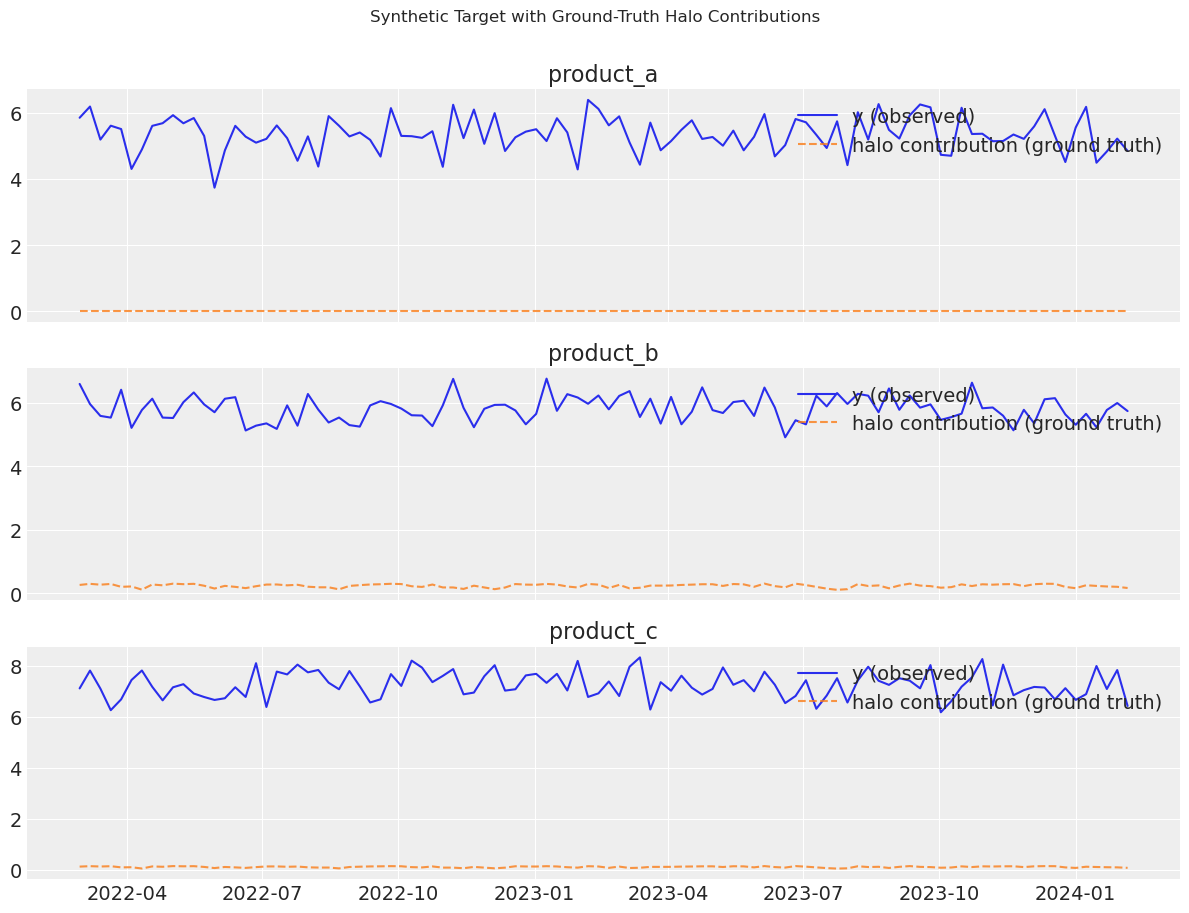

In [10]:
fig, axes = plt.subplots(N_PRODUCTS, 1, figsize=(12, 3 * N_PRODUCTS), sharex=True)
for ip, product in enumerate(PRODUCTS):
    ax = axes[ip]
    mask = data_df["product"] == product
    ax.plot(data_df.loc[mask, "date"], data_df.loc[mask, "y"], label="y (observed)")
    ax.plot(
        date_range_trimmed,
        halo_true_trimmed[:, ip],
        label="halo contribution (ground truth)",
        linestyle="--",
        alpha=0.8,
    )
    ax.set_title(product)
    ax.legend(loc="upper right")
fig.suptitle("Synthetic Target with Ground-Truth Halo Contributions", y=1.01)
fig.tight_layout()

---
## 3. Baseline — Standard Multi-Dimensional MMM (No Halo)

We fit the standard `MMM` class with `dims=("product",)`.  This model has no
mechanism for cross-product spillover; any halo-driven sales will be absorbed
into the intercept or direct channel contributions.

In [11]:
X_baseline = data_df.drop(columns=["y"])
y_baseline = data_df["y"]

mmm_baseline = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    target_column="y",
    adstock=GeometricAdstock(l_max=L_MAX),
    saturation=LogisticSaturation(),
    dims=("product",),
)

mmm_baseline.build_model(X_baseline, y_baseline)

In [12]:
mmm_baseline.fit(X=X_baseline, y=y_baseline, **SAMPLER_CONFIG)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.26,15
,2000,1,0.28,31


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data
	> fit_data

Warmup iterations saved (warmup_*).

In [13]:
mmm_baseline.sample_posterior_predictive(X=X_baseline, random_seed=RANDOM_SEED)

Sampling: [y]


Output()

<xarray.Dataset> Size: 5MB
Dimensions:  (date: 102, product: 3, sample: 2000)
Coordinates:
  * date     (date) datetime64[ns] 816B 2022-02-28 2022-03-07 ... 2024-02-05
  * product  (product) <U9 108B 'product_a' 'product_b' 'product_c'
  * sample   (sample) object 16kB MultiIndex
  * chain    (sample) int64 16kB 0 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1 1
  * draw     (sample) int64 16kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y        (date, product, sample) float64 5MB 0.7038 0.5339 ... 0.8866 0.8826
Attributes:
    created_at:                 2026-03-23T11:12:15.851499+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1

Text(0.5, 1.02, 'Baseline MMM — Posterior Predictive')

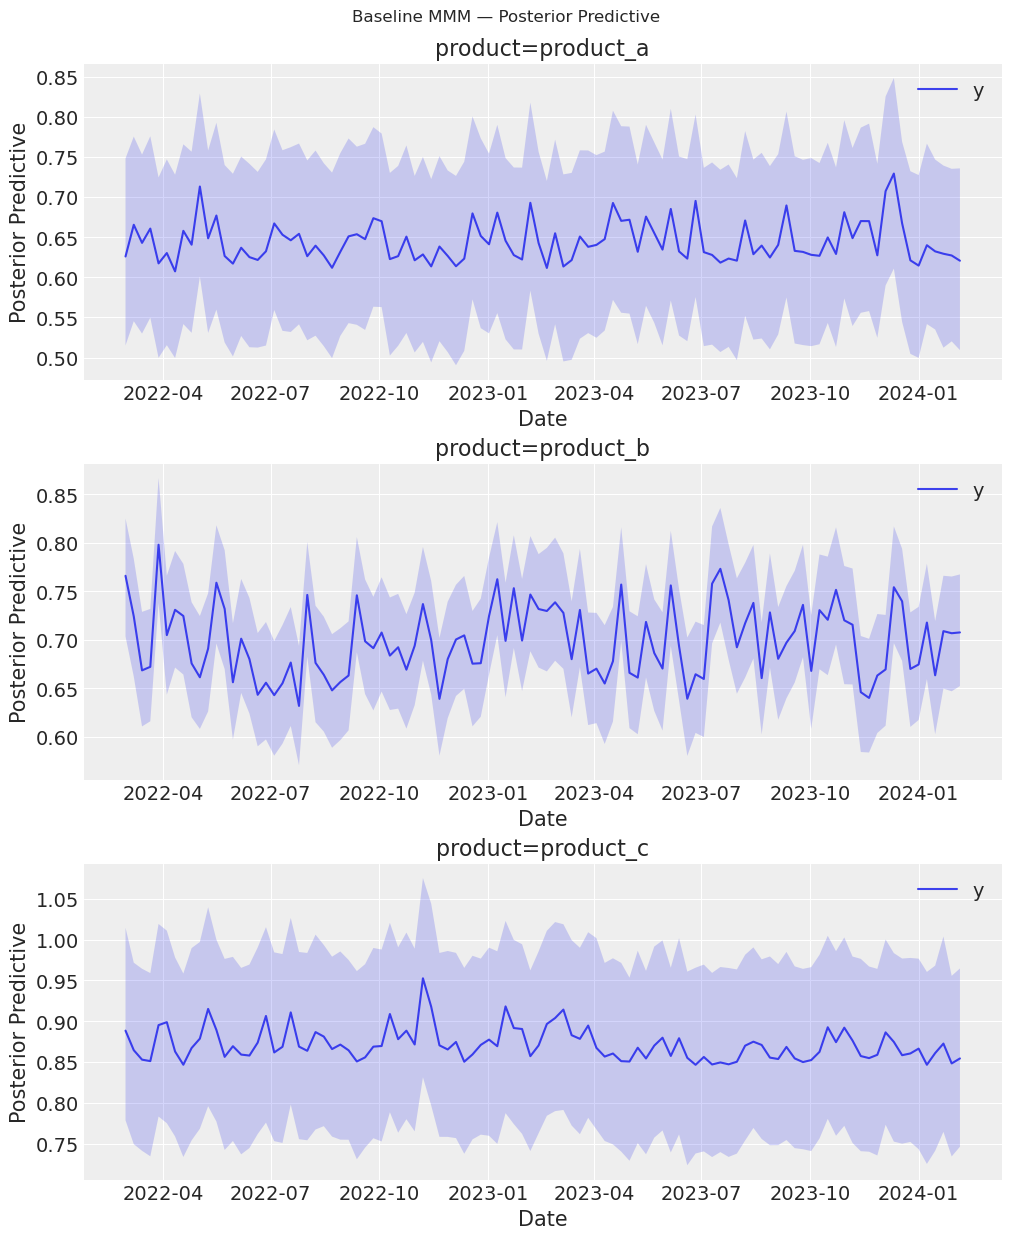

In [14]:
fig, axes = mmm_baseline.plot.posterior_predictive(var=["y"], hdi_prob=0.94)
fig.suptitle("Baseline MMM — Posterior Predictive", y=1.02)

---
## 4. Approach 0 — Aggregate Cross-Product Spend

The simplest halo proxy: for each product, compute the total media spend from
all *other* products and pass it as a `control_columns` entry to the `MMM` class.

$$
S_{t,i}^{\text{other}} = \sum_{j \neq i} \sum_{m} x_{m,t,j},
\qquad
y_{t,i} = \alpha_i + C_{t,i}
  + \gamma_i\, S_{t,i}^{\text{other}}
  + \varepsilon_{t,i}
$$

In [15]:
data_df["total_spend"] = data_df[CHANNELS].sum(axis=1)
date_total_spend = data_df.groupby("date")["total_spend"].transform("sum")
data_df["other_spend"] = date_total_spend - data_df["total_spend"]

In [16]:
X_approach0 = data_df.drop(columns=["y", "total_spend"])
y_approach0 = data_df["y"]

mmm_approach0 = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    control_columns=["other_spend"],
    target_column="y",
    adstock=GeometricAdstock(l_max=L_MAX),
    saturation=LogisticSaturation(),
    dims=("product",),
)

mmm_approach0.build_model(X_approach0, y_approach0)

In [17]:
mmm_approach0.fit(X=X_approach0, y=y_approach0, **SAMPLER_CONFIG)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,2,0.25,15
,2000,1,0.24,31


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data
	> fit_data

Warmup iterations saved (warmup_*).

In [18]:
mmm_approach0.sample_posterior_predictive(X=X_approach0, random_seed=RANDOM_SEED)

Sampling: [y]


Output()

<xarray.Dataset> Size: 5MB
Dimensions:  (date: 102, product: 3, sample: 2000)
Coordinates:
  * date     (date) datetime64[ns] 816B 2022-02-28 2022-03-07 ... 2024-02-05
  * product  (product) <U9 108B 'product_a' 'product_b' 'product_c'
  * sample   (sample) object 16kB MultiIndex
  * chain    (sample) int64 16kB 0 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1 1
  * draw     (sample) int64 16kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y        (date, product, sample) float64 5MB 0.7379 0.6035 ... 0.873 0.867
Attributes:
    created_at:                 2026-03-23T11:12:23.866877+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1

Text(0.5, 1.02, 'Approach 0 — Aggregate Cross-Product Spend (Posterior Predictive)')

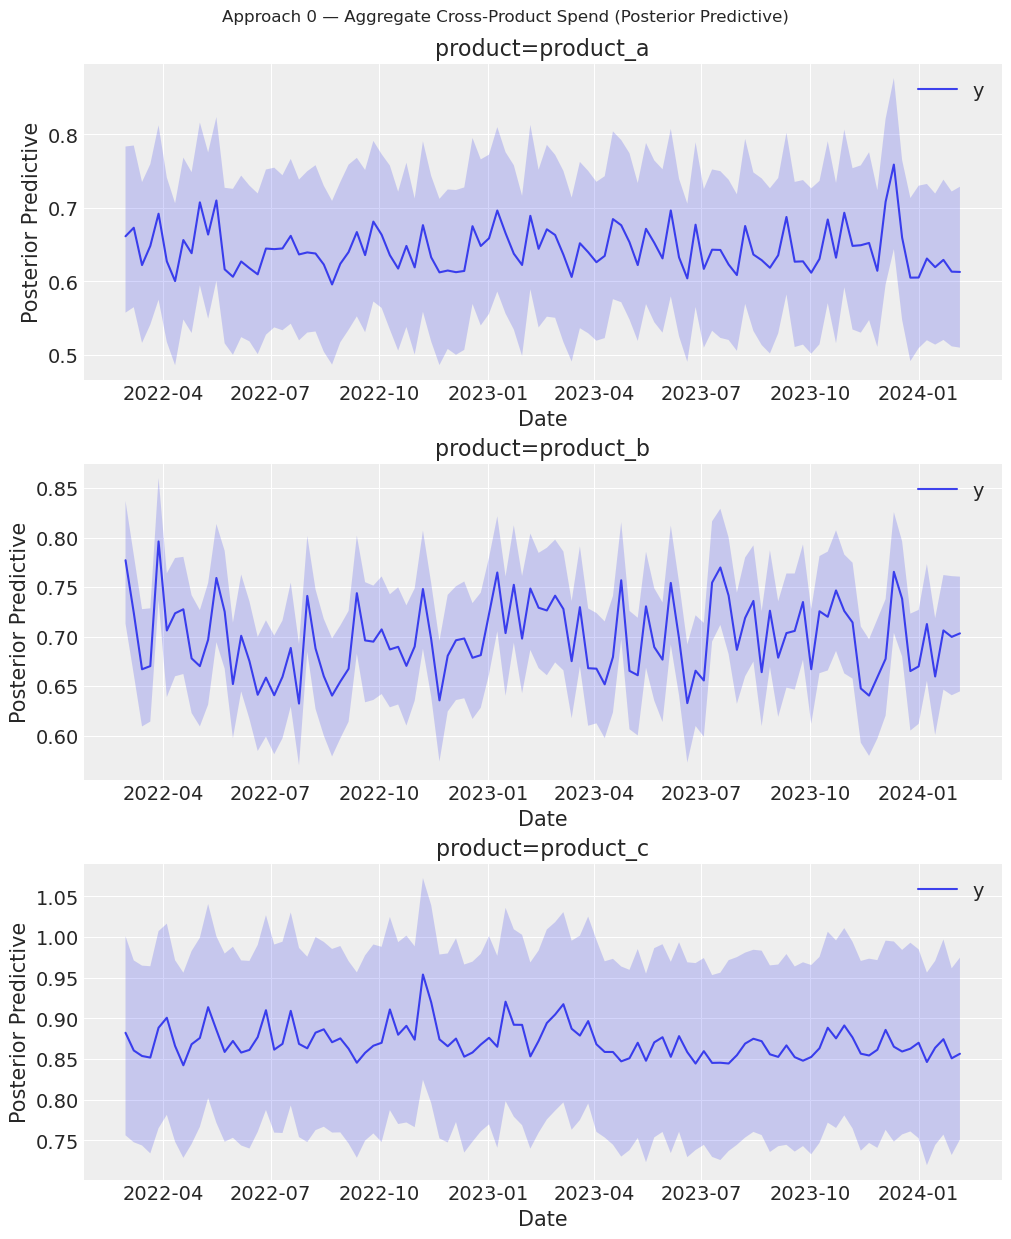

In [19]:
fig, axes = mmm_approach0.plot.posterior_predictive(var=["y"], hdi_prob=0.94)
fig.suptitle(
    "Approach 0 — Aggregate Cross-Product Spend (Posterior Predictive)", y=1.02
)

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/171808564.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


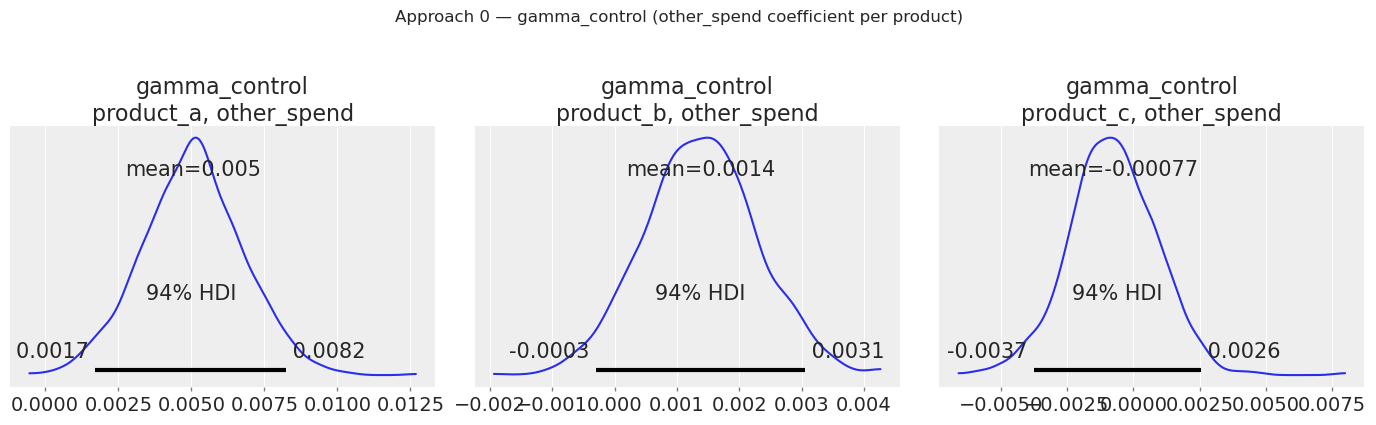

In [20]:
az.plot_posterior(mmm_approach0.idata, var_names=["gamma_control"], figsize=(14, 4))
plt.suptitle("Approach 0 — gamma_control (other_spend coefficient per product)", y=1.05)
plt.tight_layout()

---
## Helper: Build Standard Channel Contributions (reused by Approaches 1-3)

All three halo-aware models share the same channel contribution structure.
We factor it into a helper function to avoid repetition.

In [21]:
def build_channel_contributions(coords_dict, channel_data_np):
    """Build the standard adstock + saturation channel contributions.

    Must be called inside a ``pm.Model()`` context.
    Returns (channel_contribution, total_by_product) xtensor variables.
    """
    channel_data = pmd.Data(
        "channel_data", channel_data_np, dims=("date", "product", "channel")
    )

    alpha_ad = pmd.Beta("alpha_ad", alpha=1, beta=3, dims=("product", "channel"))
    adstocked = geometric_adstock(
        channel_data, alpha=alpha_ad, l_max=L_MAX, dim="date", normalize=True
    )

    lam = pmd.Gamma("lam", alpha=2, beta=1, dims=("product", "channel"))
    beta_ch = pmd.HalfNormal("beta_ch", sigma=1, dims=("product", "channel"))
    contribution = beta_ch * logistic_saturation(adstocked, lam)
    contribution = pmd.Deterministic(
        "channel_contribution", contribution.transpose("date", ...)
    )

    total = pmd.Deterministic("total_contribution", contribution.sum(dim="channel"))

    return contribution, total

---
## 5. Approach 1 — Spillover Matrix

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \sum_{j=1}^{P} H_{ij}\, C_{t,j}
  + \varepsilon_{t,i}
$$

We introduce a `product_source` coordinate to index the source dimension
of the spillover matrix $H$.

In [22]:
coords_halo = {
    "date": date_range_trimmed,
    "product": PRODUCTS,
    "channel": CHANNELS,
    "product_source": PRODUCTS,
}

# Prepare 3-D array (n_dates_trimmed, n_products, n_channels)
channel_data_3d = channel_spend_trimmed.copy()

y_target = np.zeros((n_dates_trimmed, N_PRODUCTS))
for ip, product in enumerate(PRODUCTS):
    mask = data_df["product"] == product
    y_target[:, ip] = data_df.loc[mask, "y"].values

In [23]:
with pm.Model(coords=coords_halo) as spillover_model:
    target_obs = pmd.Data("target_obs", y_target, dims=("date", "product"))

    _, total = build_channel_contributions(coords_halo, channel_data_3d)

    total_source = total.rename({"product": "product_source"})
    H = pmd.HalfNormal("H", sigma=0.3, dims=("product", "product_source"))
    halo = pmd.Deterministic(
        "halo_contribution",
        (H * total_source).sum(dim="product_source").transpose("date", ...),
    )

    intercept = pmd.Normal("intercept", mu=5, sigma=2, dims="product")
    mu = intercept + total + halo
    mu = mu.transpose("date", "product")

    sigma = pmd.HalfNormal("sigma", sigma=1, dims="product")
    pmd.Normal("y", mu=mu, sigma=sigma, observed=target_obs, dims=("date", "product"))

In [24]:
with spillover_model:
    idata_spillover = pm.sample(**SAMPLER_CONFIG)
    idata_spillover.extend(
        pm.sample_posterior_predictive(idata_spillover, random_seed=RANDOM_SEED)
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,20,0.17,63
,2000,24,0.18,63


Sampling: [y]


Output()

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/561862403.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


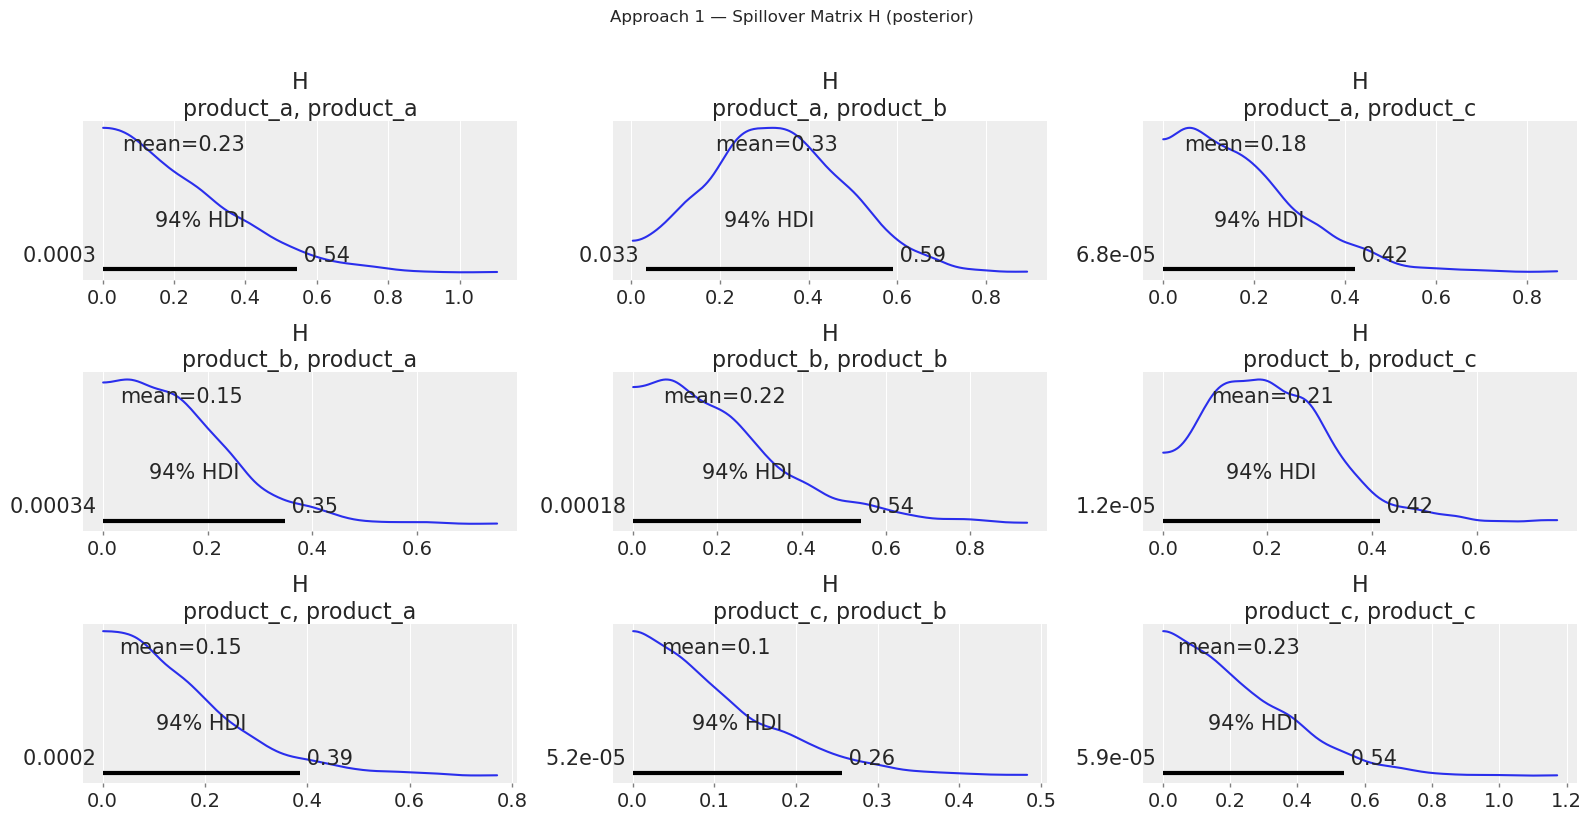

In [25]:
az.plot_posterior(idata_spillover, var_names=["H"], figsize=(16, 8))
plt.suptitle("Approach 1 — Spillover Matrix H (posterior)", y=1.02)
plt.tight_layout()

---
## 6. Approach 2 — Latent Brand Awareness Factor

$$
A_t = \sum_j w_j\, C_{t,j},
\qquad
y_{t,i} = \alpha_i + C_{t,i} + \lambda_i\, A_t + \varepsilon_{t,i}
$$

In [26]:
coords_awareness = {
    "date": date_range_trimmed,
    "product": PRODUCTS,
    "channel": CHANNELS,
}

with pm.Model(coords=coords_awareness) as awareness_model:
    target_obs = pmd.Data("target_obs", y_target, dims=("date", "product"))

    _, total = build_channel_contributions(coords_awareness, channel_data_3d)

    w_raw = pmd.HalfNormal("w_raw", sigma=1.0, dims="product")
    w = pmd.Deterministic("w", w_raw / w_raw.sum(dim="product"))
    brand_awareness = pmd.Deterministic(
        "brand_awareness", (w * total).sum(dim="product")
    )

    lam_halo = pmd.HalfNormal("lam_halo", sigma=0.5, dims="product")
    halo = pmd.Deterministic(
        "halo_contribution", (lam_halo * brand_awareness).transpose("date", ...)
    )

    intercept = pmd.Normal("intercept", mu=5, sigma=2, dims="product")
    mu = intercept + total + halo
    mu = mu.transpose("date", "product")

    sigma = pmd.HalfNormal("sigma", sigma=1, dims="product")
    pmd.Normal("y", mu=mu, sigma=sigma, observed=target_obs, dims=("date", "product"))

In [27]:
with awareness_model:
    idata_awareness = pm.sample(**SAMPLER_CONFIG)
    idata_awareness.extend(
        pm.sample_posterior_predictive(idata_awareness, random_seed=RANDOM_SEED)
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,14,0.20,63
,2000,15,0.16,31


Sampling: [y]


Output()

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/1166451625.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


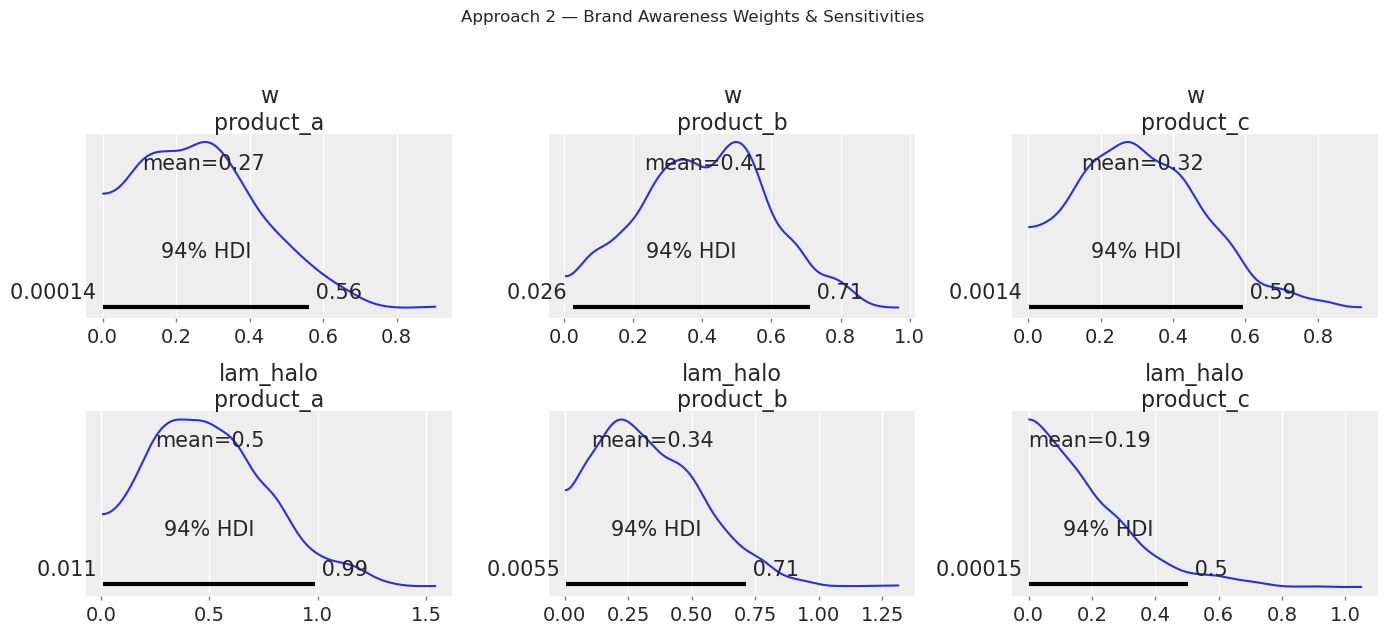

In [28]:
axes = az.plot_posterior(idata_awareness, var_names=["w", "lam_halo"], figsize=(14, 6))
plt.suptitle("Approach 2 — Brand Awareness Weights & Sensitivities", y=1.05)
plt.tight_layout()

---
## 7. Approach 3 — Flagship-Specific Halo

$$
y_{t,i} = \alpha_i + C_{t,i}
  + \delta_i\, C_{t,\text{flagship}}
  + \varepsilon_{t,i}
$$

This matches the DGP exactly, so it should recover the ground truth
$\delta = [0.0, 0.3, 0.15]$ most accurately.

In [29]:
coords_flagship = {
    "date": date_range_trimmed,
    "product": PRODUCTS,
    "channel": CHANNELS,
}

with pm.Model(coords=coords_flagship) as flagship_model:
    target_obs = pmd.Data("target_obs", y_target, dims=("date", "product"))

    _, total = build_channel_contributions(coords_flagship, channel_data_3d)

    flagship_total = total.isel(product=FLAGSHIP_IDX)
    delta = pmd.HalfNormal("delta", sigma=0.5, dims="product")
    halo = pmd.Deterministic(
        "halo_contribution", (delta * flagship_total).transpose("date", ...)
    )

    intercept = pmd.Normal("intercept", mu=5, sigma=2, dims="product")
    mu = intercept + total + halo
    mu = mu.transpose("date", "product")

    sigma = pmd.HalfNormal("sigma", sigma=1, dims="product")
    pmd.Normal("y", mu=mu, sigma=sigma, observed=target_obs, dims=("date", "product"))

In [30]:
with flagship_model:
    idata_flagship = pm.sample(**SAMPLER_CONFIG)
    idata_flagship.extend(
        pm.sample_posterior_predictive(idata_flagship, random_seed=RANDOM_SEED)
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,10,0.20,63
,2000,12,0.20,31


Sampling: [y]


Output()

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/3432987.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


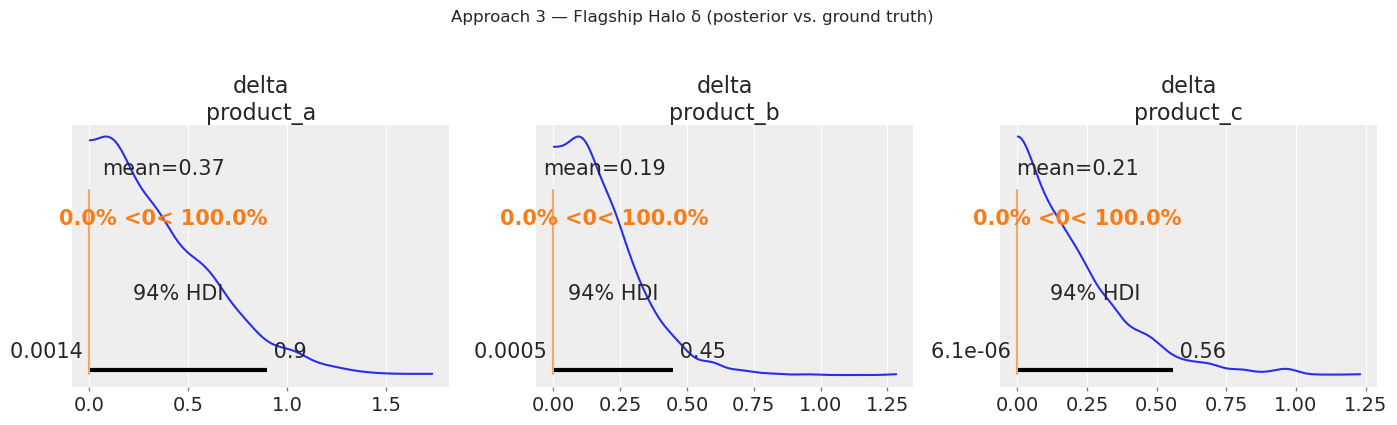

In [31]:
az.plot_posterior(
    idata_flagship,
    var_names=["delta"],
    ref_val={"delta": [{"ref_val": v} for v in delta_true]},
    figsize=(14, 4),
)
plt.suptitle("Approach 3 — Flagship Halo \u03b4 (posterior vs. ground truth)", y=1.05)
plt.tight_layout()

---
## 8. Results Comparison

### 8.1 Posterior Predictive Comparison

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/1519983700.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


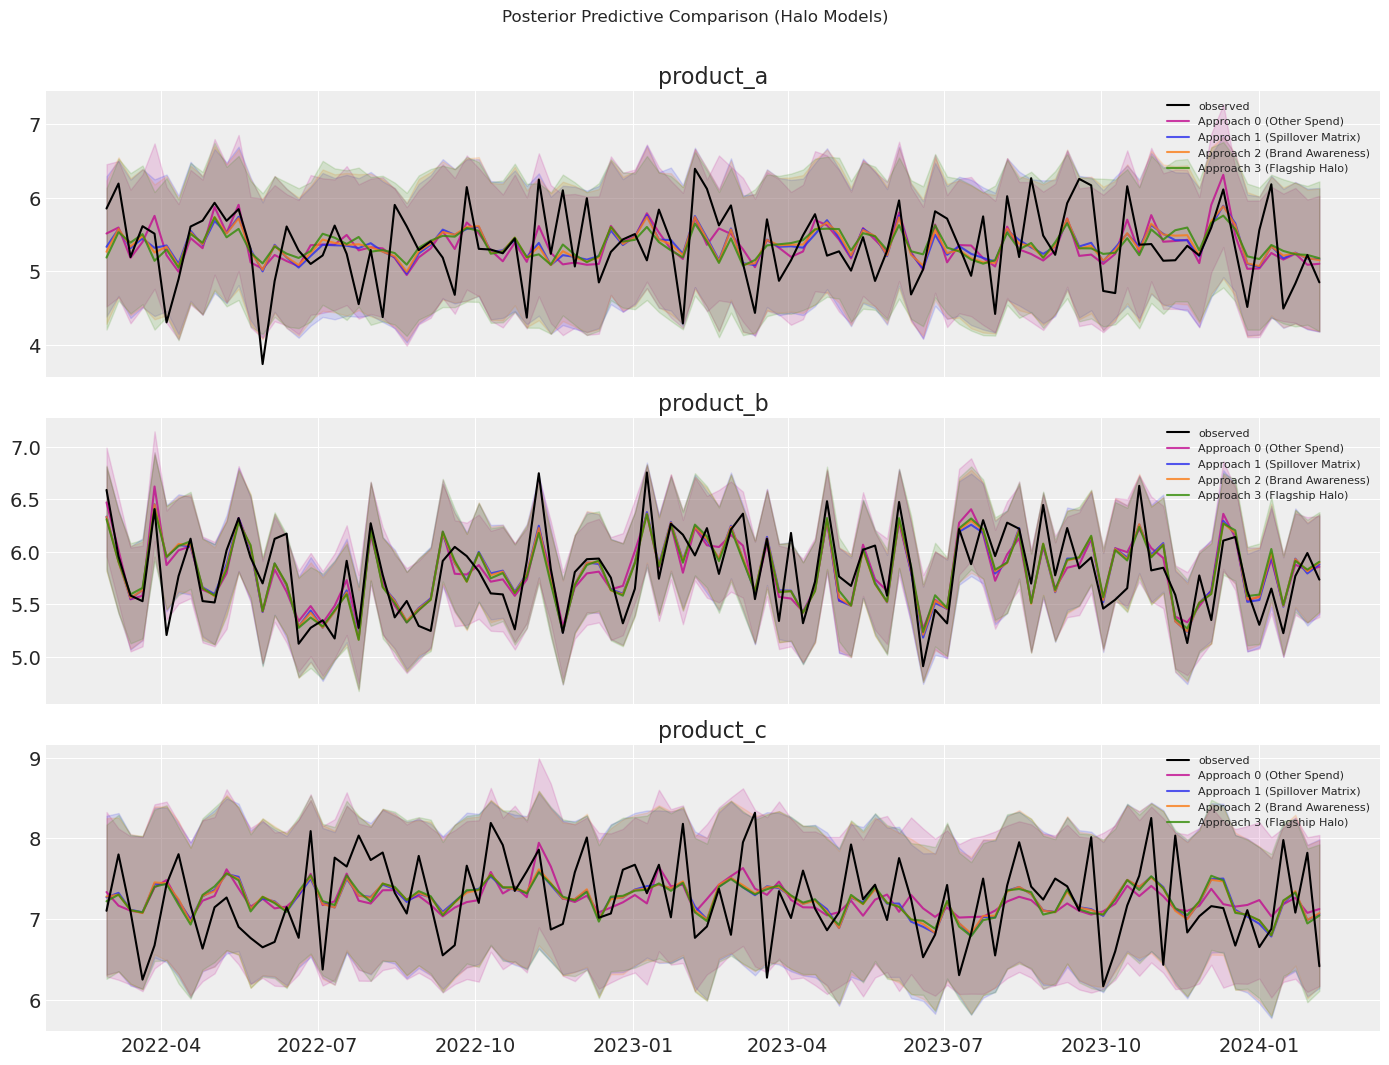

In [32]:
fig, axes = plt.subplots(N_PRODUCTS, 1, figsize=(14, 3.5 * N_PRODUCTS), sharex=True)

model_labels = [
    "Approach 0 (Other Spend)",
    "Approach 1 (Spillover Matrix)",
    "Approach 2 (Brand Awareness)",
    "Approach 3 (Flagship Halo)",
]
colors = ["C3", "C0", "C1", "C2"]

# The MMM class scales the target internally; unscale its posterior predictive
# so all models are compared on the original data scale.
# Extract as numpy: (chain, draw, date, product)
approach0_pp_scaled = mmm_approach0.idata.posterior_predictive["y"].values
approach0_scale = mmm_approach0.idata.constant_data["target_scale"].values
approach0_pp_np = approach0_pp_scaled * approach0_scale

pp_np_arrays = [
    approach0_pp_np,
    idata_spillover.posterior_predictive["y"].values,
    idata_awareness.posterior_predictive["y"].values,
    idata_flagship.posterior_predictive["y"].values,
]

for ip, product in enumerate(PRODUCTS):
    ax = axes[ip]
    ax.plot(
        date_range_trimmed, y_target[:, ip], "k-", lw=1.5, label="observed", zorder=5
    )

    for label, pp_np, color in zip(model_labels, pp_np_arrays, colors, strict=True):
        pp_mean = pp_np.mean(axis=(0, 1))[:, ip]
        pp_low = np.quantile(pp_np, 0.03, axis=(0, 1))[:, ip]
        pp_high = np.quantile(pp_np, 0.97, axis=(0, 1))[:, ip]
        ax.plot(date_range_trimmed, pp_mean, color=color, alpha=0.8, label=label)
        ax.fill_between(
            date_range_trimmed,
            pp_low,
            pp_high,
            color=color,
            alpha=0.15,
        )

    ax.set_title(product)
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Posterior Predictive Comparison (Halo Models)", y=1.01)
fig.tight_layout()

### 8.2 Halo Parameter Recovery

The DGP used $\delta = [0.0, 0.3, 0.15]$.  We compare what each approach
recovered.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/1665122217.py:50: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


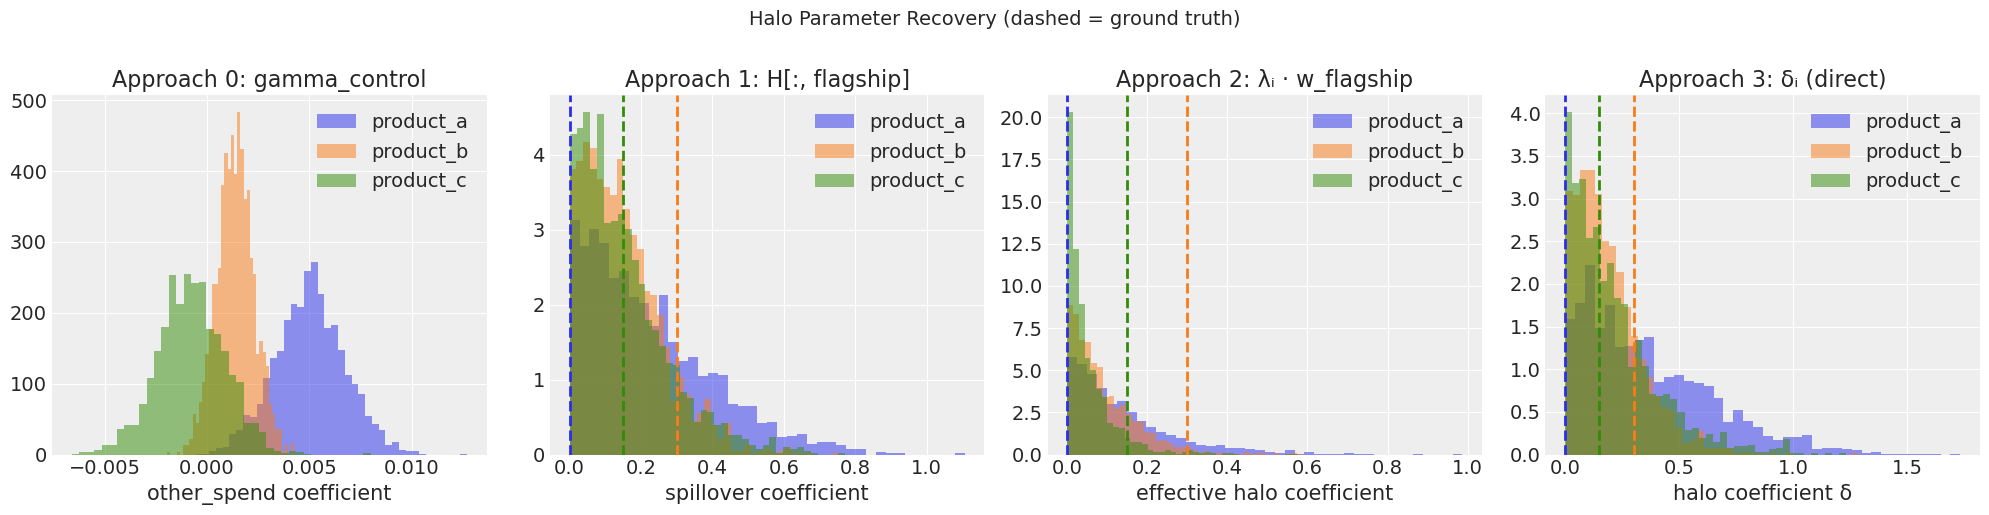

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# --- Approach 0: gamma_control (other_spend coefficient)
ax = axes[0]
gamma_post = mmm_approach0.idata.posterior["gamma_control"]
for _ip, product in enumerate(PRODUCTS):
    vals = gamma_post.sel(product=product, control="other_spend").values.flatten()
    ax.hist(vals, bins=40, alpha=0.5, label=product, density=True)
ax.set_title("Approach 0: gamma_control")
ax.set_xlabel("other_spend coefficient")
ax.legend()

# --- Approach 1: Spillover matrix H — extract the flagship column (column 0)
ax = axes[1]
H_post = idata_spillover.posterior["H"]
H_from_flagship = H_post.sel(product_source=PRODUCTS[FLAGSHIP_IDX])
for ip, product in enumerate(PRODUCTS):
    vals = H_from_flagship.sel(product=product).values.flatten()
    ax.hist(vals, bins=40, alpha=0.5, label=product, density=True)
    ax.axvline(delta_true[ip], color=f"C{ip}", linestyle="--", lw=2)
ax.set_title("Approach 1: H[:, flagship]")
ax.set_xlabel("spillover coefficient")
ax.legend()

# --- Approach 2: lambda_i * w_flagship
ax = axes[2]
w_post = idata_awareness.posterior["w"]
lam_post = idata_awareness.posterior["lam_halo"]
w_flagship = w_post.sel(product=PRODUCTS[FLAGSHIP_IDX])
for ip, product in enumerate(PRODUCTS):
    effective = (lam_post.sel(product=product) * w_flagship).values.flatten()
    ax.hist(effective, bins=40, alpha=0.5, label=product, density=True)
    ax.axvline(delta_true[ip], color=f"C{ip}", linestyle="--", lw=2)
ax.set_title("Approach 2: \u03bbᵢ \u00b7 w_flagship")
ax.set_xlabel("effective halo coefficient")
ax.legend()

# --- Approach 3: delta directly
ax = axes[3]
delta_post = idata_flagship.posterior["delta"]
for ip, product in enumerate(PRODUCTS):
    vals = delta_post.sel(product=product).values.flatten()
    ax.hist(vals, bins=40, alpha=0.5, label=product, density=True)
    ax.axvline(delta_true[ip], color=f"C{ip}", linestyle="--", lw=2)
ax.set_title("Approach 3: \u03b4\u1d62 (direct)")
ax.set_xlabel("halo coefficient \u03b4")
ax.legend()

fig.suptitle("Halo Parameter Recovery (dashed = ground truth)", y=1.02, fontsize=14)
fig.tight_layout()

### 8.3 Summary Table

In [34]:
summary_rows = []
for label, pp_np in zip(model_labels, pp_np_arrays, strict=True):
    residuals = pp_np.mean(axis=(0, 1)) - y_target
    rmse = np.sqrt((residuals**2).mean())
    summary_rows.append({"Model": label, "RMSE (in-sample)": round(rmse, 4)})

summary_table = pd.DataFrame(summary_rows)
print(summary_table.to_string(index=False))

                        Model  RMSE (in-sample)
     Approach 0 (Other Spend)            0.4118
Approach 1 (Spillover Matrix)            0.4092
 Approach 2 (Brand Awareness)            0.4095
   Approach 3 (Flagship Halo)            0.4147


### 8.4 Discussion

- **Approach 0 (Aggregate Cross-Product Spend)** is the quickest way to add a
  halo proxy using the `MMM` class.  The `gamma_control` coefficient captures
  whether aggregate spend from other products correlates with each product's
  sales, but it operates on *raw* spend (no adstock or saturation) and cannot
  distinguish *which* product's spend drives the halo.
- **Approach 3 (Flagship Halo)** matches the DGP and should recover the true
  $\delta$ values most accurately.  The posterior for `delta[product_a]` should
  concentrate near 0, confirming no self-halo.
- **Approach 1 (Spillover Matrix)** is more flexible but has $P^2$ parameters.
  The diagonal and off-diagonal elements of $H$ compete for variance, making
  identification harder.
- **Approach 2 (Brand Awareness)** captures the qualitative halo pattern but
  is a rank-1 approximation -- the product $\lambda_i \cdot w_j$ may not
  perfectly recover the true $\delta$ structure.
- **The Baseline MMM** (not shown in the halo comparison plots) absorbs the
  halo effect into the intercept and direct channel contributions, leading to
  inflated ROAS estimates for non-flagship products and deflated estimates for
  the flagship.

---
## 9. Halo Effects as `MuEffect` Components

Approaches 1-3 above were implemented as fully custom `pm.Model` builds.
This gives maximum flexibility but loses integration with the `MMM` class
(posterior predictive via `sample_posterior_predictive`, budget optimisation,
model serialisation, etc.).

The `MMM` class supports an extensibility mechanism called **`MuEffect`**
(defined in `pymc_marketing.mmm.additive_effect`).  Any object that implements
the three-method protocol -- `create_data`, `create_effect`, `set_data` -- can
be appended to `mmm.mu_effects` before `build_model`.  During model
construction the effect's `create_effect` is called **after**
`channel_contribution` has been registered as a `pmd.Deterministic`, so a
`MuEffect` can access `mmm.model["channel_contribution"]` to derive halo
terms from the already-adstocked/saturated channel contributions.

Below we define three `MuEffect` subclasses -- one for each halo approach --
and demonstrate the flagship halo variant end-to-end.

### 9.1 Defining the MuEffect Subclasses

In [35]:
class FlagshipHaloEffect(MuEffect):
    """Approach 3 -- Flagship-specific halo as a MuEffect."""

    flagship_idx: int = 0
    sigma_delta: float = 0.5

    def create_data(self, mmm):
        """No extra data needed; derives from channel_contribution."""

    def create_effect(self, mmm):
        """Add flagship halo: delta_i * C_{t, flagship}."""
        total = mmm.model["channel_contribution"].sum(dim="channel")
        flagship_total = total.isel(product=self.flagship_idx)
        delta = pmd.HalfNormal("delta_halo", sigma=self.sigma_delta, dims=mmm.dims)
        return pmd.Deterministic(
            "halo_contribution",
            (delta * flagship_total).transpose("date", ...),
        )

    def set_data(self, mmm, model, X):
        """No-op: halo recomputes from updated channel data."""


class SpilloverMatrixEffect(MuEffect):
    """Approach 1 -- Full spillover matrix as a MuEffect."""

    sigma_H: float = 0.3
    product_dim: str = "product"

    def create_data(self, mmm):
        """Register the product_source coordinate."""
        mmm.model.add_coord("product_source", mmm.model.coords[self.product_dim])

    def create_effect(self, mmm):
        """Add spillover: sum_j H_ij * C_{t,j}."""
        total = mmm.model["channel_contribution"].sum(dim="channel")
        total_source = total.rename({self.product_dim: "product_source"})
        H = pmd.HalfNormal(
            "H",
            sigma=self.sigma_H,
            dims=(self.product_dim, "product_source"),
        )
        return pmd.Deterministic(
            "halo_contribution",
            (H * total_source).sum(dim="product_source").transpose("date", ...),
        )

    def set_data(self, mmm, model, X):
        """No-op: halo recomputes from updated channel data."""


class BrandAwarenessEffect(MuEffect):
    """Approach 2 -- Latent brand awareness factor as a MuEffect."""

    sigma_lam: float = 0.5
    product_dim: str = "product"

    def create_data(self, mmm):
        """No extra data needed; derives from channel_contribution."""

    def create_effect(self, mmm):
        """Add latent brand awareness: lam_i * sum_j w_j * C_{t,j}."""
        total = mmm.model["channel_contribution"].sum(dim="channel")
        w_raw = pmd.HalfNormal("w_raw", sigma=1.0, dims=self.product_dim)
        w = pmd.Deterministic("w", w_raw / w_raw.sum(dim=self.product_dim))
        awareness = pmd.Deterministic(
            "brand_awareness",
            (w * total).sum(dim=self.product_dim),
        )
        lam_halo = pmd.HalfNormal(
            "lam_halo",
            sigma=self.sigma_lam,
            dims=self.product_dim,
        )
        return pmd.Deterministic(
            "halo_contribution",
            (lam_halo * awareness).transpose("date", ...),
        )

    def set_data(self, mmm, model, X):
        """No-op: halo recomputes from updated channel data."""

### 9.2 Fitting the Flagship Halo via `MMM` + `MuEffect`

We fit the same data using the `MMM` class with a `FlagshipHaloEffect`
appended, then compare the recovered `delta_halo` posterior to the ground
truth and to the custom-model Approach 3 results from Section 7.

In [36]:
mmm_halo = MMM(
    date_column="date",
    channel_columns=CHANNELS,
    target_column="y",
    adstock=GeometricAdstock(l_max=L_MAX),
    saturation=LogisticSaturation(),
    dims=("product",),
)

mmm_halo.mu_effects.append(
    FlagshipHaloEffect(flagship_idx=FLAGSHIP_IDX, sigma_delta=0.5)
)

mmm_halo.build_model(X_baseline, y_baseline)

In [37]:
mmm_halo.fit(X=X_baseline, y=y_baseline, **SAMPLER_CONFIG)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.22,15
,2000,0,0.24,31


Output()

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data
	> fit_data

Warmup iterations saved (warmup_*).

In [38]:
mmm_halo.sample_posterior_predictive(X=X_baseline, random_seed=RANDOM_SEED)

Sampling: [y]


Output()

<xarray.Dataset> Size: 5MB
Dimensions:  (date: 102, product: 3, sample: 2000)
Coordinates:
  * date     (date) datetime64[ns] 816B 2022-02-28 2022-03-07 ... 2024-02-05
  * product  (product) <U9 108B 'product_a' 'product_b' 'product_c'
  * sample   (sample) object 16kB MultiIndex
  * chain    (sample) int64 16kB 0 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1 1
  * draw     (sample) int64 16kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y        (date, product, sample) float64 5MB 0.672 0.5787 ... 0.872 0.8611
Attributes:
    created_at:                 2026-03-23T11:13:00.902427+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1

### 9.3 Comparing `delta_halo` Recovery

The ground truth is $\delta = [0.0, 0.3, 0.15]$.  We overlay the MMM-based
`delta_halo` posterior (from this section) with the custom-model `delta`
posterior (from Approach 3 in Section 7).

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_45308/2402330081.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


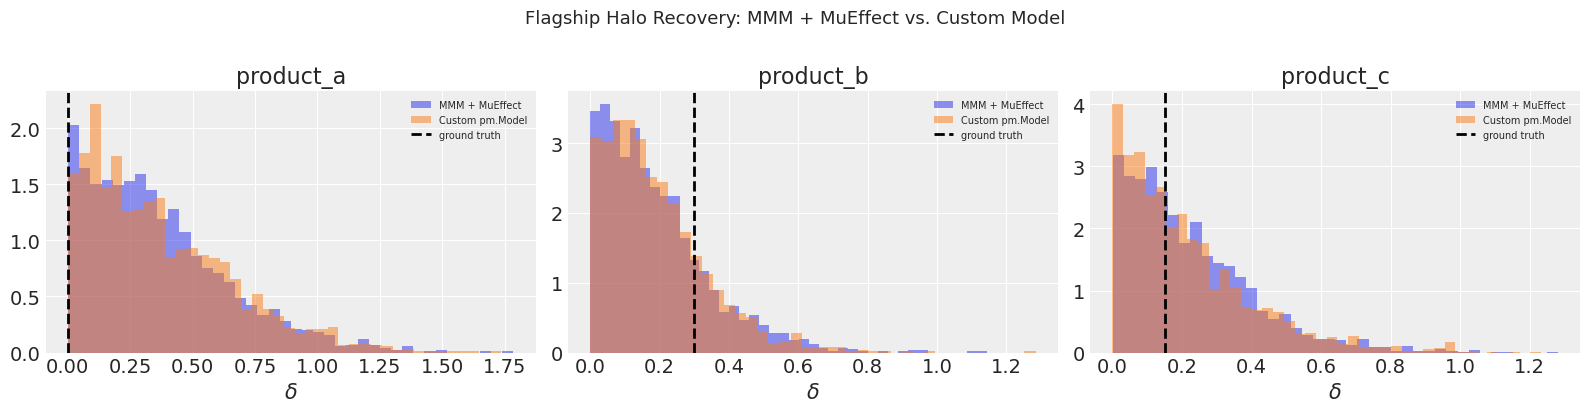

In [39]:
fig, axes = plt.subplots(1, N_PRODUCTS, figsize=(16, 4))

delta_mmm = mmm_halo.idata.posterior["delta_halo"]
delta_custom = idata_flagship.posterior["delta"]

for ip, product in enumerate(PRODUCTS):
    ax = axes[ip]
    vals_mmm = delta_mmm.sel(product=product).values.flatten()
    vals_custom = delta_custom.sel(product=product).values.flatten()
    ax.hist(vals_mmm, bins=40, alpha=0.5, label="MMM + MuEffect", density=True)
    ax.hist(vals_custom, bins=40, alpha=0.5, label="Custom pm.Model", density=True)
    ax.axvline(delta_true[ip], color="k", linestyle="--", lw=2, label="ground truth")
    ax.set_title(product)
    ax.set_xlabel(r"$\delta$")
    ax.legend(fontsize=7)

fig.suptitle(
    "Flagship Halo Recovery: MMM + MuEffect vs. Custom Model", y=1.02, fontsize=13
)
fig.tight_layout()

### 9.4 Trade-offs

| | Custom `pm.Model` | `MMM` + `MuEffect` |
|---|---|---|
| **Flexibility** | Full control | Within `MMM` scaffold |
| **Posterior pred.** | Manual | `mmm.sample_posterior_predictive` |
| **Budget optim.** | Not available | `compute_optimal_budget_allocation` |
| **Serialisation** | Manual | Automatic (with effect registry) |
| **Channel contrib.** | Self-managed | Provided by `MMM` |

For production use, the `MuEffect` route is preferred because it preserves
the full `MMM` workflow.  The custom-model route remains useful for rapid
prototyping or when the halo structure does not fit the additive `mu_effect`
pattern.